# OpenUniverse2024 — Ruta A: light curves de transientes desde el truth index

Arma light curves multibanda de Roman directamente desde los archivos por exposición
`Roman_TDS_index_<BAND>_<POINTING>_<SCA>.txt` (producto `RomanTDS/truth`, ~37 GB totales,
aquí se subsetea un puñado de pointings), uniendo:

- **obseq** (`Roman_TDS_obseq_*.fits`) — cada `pointing` → MJD, filtro, RA/Dec, exptime.
- **SkyCatalog `snana`** (`snana_10307.parquet`) — `id` → clase (`gentype`/`model_name`), redshift, peak MJD.

No descarga ninguna imagen. Cada index file trae `realized_flux` (con ruido Poisson) y `flux`/`mag` (verdaderos).


In [1]:
import urllib.request
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from astropy.visualization import ZScaleInterval
import galsim
import galsim.roman as roman

BASE = "https://irsa.ipac.caltech.edu/data/theory/openuniverse2024/roman/preview"
TRUTH_BASE = f"{BASE}/RomanTDS/truth"
IMAGE_BASE = f"{BASE}/RomanTDS/images/simple_model"
OBSEQ_URL = f"{BASE}/RomanTDS/Roman_TDS_obseq_11_6_23.fits"
SNANA_PARQUET_URL = f"{BASE}/roman_rubin_cats_v1.1.2_faint/snana_10307.parquet"

CACHE_DIR = Path("openuniverse_cache")
CACHE_DIR.mkdir(exist_ok=True)

FIELD_CENTER_RA, FIELD_CENTER_DEC = 9.5, -44.3
SELECTION_RADIUS_DEG = 0.12
POINTINGS_PER_BAND = 6
NUMBER_OF_TRANSIENTS = 10
SCA_NUMBERS = range(1, 19)
SNR_DETECTION = 5.0  # SNR >= 5 -> detection; below -> 5sigma upper limit (Roman convention)

INDEX_COLUMNS = ["object_id", "ra", "dec", "x", "y", "realized_flux", "flux", "mag", "obj_type"]

BANDS_BY_WAVELENGTH = ["R062", "Z087", "Y106", "J129", "H158", "F184", "K213"]
BAND_WAVELENGTH_MICRON = {"R062": 0.62, "Z087": 0.87, "Y106": 1.06, "J129": 1.29,
                          "H158": 1.58, "F184": 1.84, "K213": 2.13}
# Paleta de hourglass_eda.ipynb: turbo en linspace(0.05, 0.95) sobre R Z Y J H F (inicial de banda).
_BAND_LETTER_ORDER = ["R", "Z", "Y", "J", "H", "F"]
_BAND_LETTER_COLOR = {letter: plt.cm.turbo(position) for letter, position
                      in zip(_BAND_LETTER_ORDER, np.linspace(0.05, 0.95, len(_BAND_LETTER_ORDER)))}
BAND_COLOR = {band: _BAND_LETTER_COLOR.get(band[0], plt.cm.turbo(1.0))
              for band in BAND_WAVELENGTH_MICRON}

GENTYPE_LABEL = {10: "SN Ia", 12: "SN Iax", 21: "SN Ib", 26: "SN Ic", 32: "SN II",
                 40: "SLSN-I", 42: "TDE", 50: "KN", 57: "PISN-H", 58: "PISN-He", 99: "FIXMAG"}

# AB photometric calibration straight from galsim.roman (the package OpenUniverse simulated with).
# The truth index `flux` is in total collected photons; the Roman per-band zeropoint is for
# photons / second / cm^2, so: mag_AB = zeropoint - 2.5*log10(flux / exptime / collecting_area).
ROMAN_BANDPASSES = roman.getBandpasses()
ROMAN_ZEROPOINT = {band: ROMAN_BANDPASSES[band].zeropoint for band in BANDS_BY_WAVELENGTH}
COLLECTING_AREA_CM2 = roman.collecting_area

# The truth index `flux`/`realized_flux` are in total collected electrons (same units as the SCI image);
# `realized_flux` is Poisson(flux), i.e. source shot noise only, with NO background. A realistic per-epoch
# photometric error therefore has to ADD the sky/thermal/dark/read floor over the PSF noise-equivalent area:
#   sigma_flux^2 = flux_source + NEA * (sky + thermal + dark + read_noise^2)   [electrons^2]
# getSkyLevel returns the zodiacal sky in e-/arcsec^2, so it must be multiplied by the pixel area
# (pixel_scale^2) to get e-/pixel before adding the (already per-pixel) thermal/dark/read terms.
# Sanity: this gives ~666 e-/pix for F184 (901 s), the right order vs the image SKY_MEAN (~355 e-/pix).
# The prior code treated e-/arcsec^2 as e-/pixel, inflating the sky ~1/pixel_scale^2 (~83x) and so
# crushing the SNR (AB24 went from SNR~6 to SNR~42 after the fix).
EXPOSURE_TIME = {"R062": 161.025, "Z087": 101.700, "Y106": 302.275, "J129": 302.275,
                 "H158": 302.275, "F184": 901.175, "K213": 901.175}
_field_world_position = galsim.CelestialCoord(FIELD_CENTER_RA * galsim.degrees,
                                              FIELD_CENTER_DEC * galsim.degrees)
NOISE_FLOOR_VARIANCE = {}
for band in BANDS_BY_WAVELENGTH:
    exposure = EXPOSURE_TIME[band]
    # getSkyLevel devuelve e-/arcsec^2; convertir a e-/pixel con el area del pixel
    sky_level = roman.getSkyLevel(ROMAN_BANDPASSES[band], world_pos=_field_world_position,
                                  exptime=exposure) * roman.pixel_scale ** 2
    background_per_pixel = (sky_level + roman.thermal_backgrounds[band] * exposure
                            + roman.dark_current * exposure + roman.read_noise ** 2)
    point_spread_function = roman.getPSF(1, band, wavelength=ROMAN_BANDPASSES[band].effective_wavelength,
                                         pupil_bin=8).drawImage(scale=roman.pixel_scale, nx=64, ny=64).array
    point_spread_function = point_spread_function / point_spread_function.sum()
    noise_equivalent_area = 1.0 / np.sum(point_spread_function ** 2)
    NOISE_FLOOR_VARIANCE[band] = noise_equivalent_area * background_per_pixel


In [2]:
def download_file(url, destination):
    if not destination.exists():
        urllib.request.urlretrieve(url, destination)
    return destination


def angular_separation_deg(right_ascension, declination, center_ra, center_dec):
    return np.hypot((right_ascension - center_ra) * np.cos(np.radians(declination)),
                    declination - center_dec)


def load_index_file(band, pointing, sca):
    url = f"{TRUTH_BASE}/{band}/{pointing}/Roman_TDS_index_{band}_{pointing}_{sca}.txt"
    try:
        frame = pd.read_csv(url, sep=r"\s+", comment="#", names=INDEX_COLUMNS)
    except Exception:
        return None
    frame = frame[frame["obj_type"] == "transient"].copy()
    frame["band"] = band
    frame["pointing"] = pointing
    return frame


def plot_field(obseq, snana):
    figure, axis = plt.subplots(figsize=(7, 6))
    axis.scatter(obseq["ra"], obseq["dec"], s=1, color="0.85")
    transients = snana[snana["label"] != "FIXMAG"]
    separation = angular_separation_deg(transients["ra"], transients["dec"],
                                        FIELD_CENTER_RA, FIELD_CENTER_DEC)
    nearby = transients[separation < 0.4]
    for label, group in nearby.groupby("label"):
        axis.scatter(group["ra"], group["dec"], s=10, label=label)
    axis.add_patch(plt.Circle((FIELD_CENTER_RA, FIELD_CENTER_DEC), SELECTION_RADIUS_DEG,
                              fill=False, color="k", lw=1.5))
    axis.set_xlabel("RA [deg]")
    axis.set_ylabel("Dec [deg]")
    axis.set_title("TDS footprint, transients near field center, and selection circle")
    axis.legend(markerscale=2, fontsize=8, ncol=2)
    axis.set_aspect("equal")
    axis.invert_xaxis()
    plt.show()


def plot_cadence(selected_pointings):
    figure, axis = plt.subplots(figsize=(10, 3))
    for band in BANDS_BY_WAVELENGTH:
        rows = selected_pointings[selected_pointings["filter"] == band]
        axis.scatter(rows["date"], [band] * len(rows), color=BAND_COLOR[band], s=50)
    axis.set_xlabel("MJD")
    axis.set_ylabel("filter")
    axis.set_title("Selected pointings within the selection circle")
    plt.show()


def plot_detection_counts(photometry):
    counts = photometry.groupby("band").size().reindex(BANDS_BY_WAVELENGTH).fillna(0)
    figure, axis = plt.subplots(figsize=(7, 3))
    axis.bar(counts.index, counts.values, color=[BAND_COLOR[band] for band in counts.index])
    axis.set_xlabel("filter")
    axis.set_ylabel("transient detections")
    axis.set_title("Transient detections per band in the downloaded subset")
    plt.show()


def limiting_magnitude_5sigma(band, flux_error, exposure_time):
    """Per-visit 5σ limiting AB magnitude from the photometric error alone: the source is
    fainter than this. Same ZP - 2.5*log10(5*flux_err/exptime/area) recipe as the detections,
    so the non-detection depth cannot become a pipeline tell."""
    limiting_rate = SNR_DETECTION * flux_error / exposure_time / COLLECTING_AREA_CM2
    return ROMAN_ZEROPOINT[band] - 2.5 * np.log10(limiting_rate)


def plot_light_curves(photometry_subset, summary):
    columns = 5
    rows = int(np.ceil(len(summary) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3 * rows), squeeze=False)
    for axis, (_, info) in zip(axes.ravel(), summary.iterrows()):
        one_object = photometry_subset[photometry_subset["object_id"] == info["object_id"]]
        for band in BANDS_BY_WAVELENGTH:
            band_rows = one_object[one_object["band"] == band]
            if len(band_rows) == 0:
                continue
            color = BAND_COLOR[band]

            # detection: SNR >= 5 -> measured magnitude with error (circle)
            detections = band_rows[(band_rows["snr"] >= SNR_DETECTION) & band_rows["mag_ab"].notna()]
            if len(detections) > 0:
                axis.errorbar(detections["mjd"], detections["mag_ab"], yerr=detections["mag_err"],
                              fmt="o", ms=4, color=color, ecolor=color,
                              elinewidth=0.6, capsize=0, mec="k", mew=0.3)

            # non-detection: SNR < 5 -> 5σ upper limit (downward triangle, no error bar)
            upper_limits = band_rows[band_rows["snr"] < SNR_DETECTION]
            if len(upper_limits) > 0:
                limiting_mag = limiting_magnitude_5sigma(
                    band, upper_limits["flux_error"], upper_limits["exptime"])
                axis.scatter(upper_limits["mjd"], limiting_mag, marker="v",
                             s=22, color=color, edgecolor="k", linewidth=0.3, alpha=0.5)
        if np.isfinite(info["peak_mjd"]):
            axis.axvline(info["peak_mjd"], color="grey", ls=":", lw=0.8)
        axis.invert_yaxis()
        axis.set_title(f"{info['label']}  z={info['z_CMB']:.2f}", fontsize=9)
        axis.set_xlabel("MJD")
        axis.set_ylabel("AB mag")
    for axis in axes.ravel()[len(summary):]:
        axis.axis("off")
    band_handles = [plt.Line2D([], [], marker="o", ls="", color=BAND_COLOR[band], label=band)
                    for band in BANDS_BY_WAVELENGTH]
    token_handles = [plt.Line2D([], [], marker="o", ls="", color="0.4", label="detection (SNR ≥ 5)"),
                     plt.Line2D([], [], marker="v", ls="", color="0.4", label="5σ upper limit")]
    figure.legend(handles=band_handles + token_handles, loc="upper center",
                  ncol=len(band_handles) + len(token_handles), frameon=False)
    figure.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_image_with_marker(science, mark_xy, title, half_width=30):
    x, y = mark_xy
    column, row = int(round(x)), int(round(y))
    cutout = science[row - half_width:row + half_width, column - half_width:column + half_width]
    interval = ZScaleInterval()
    figure, (full_axis, zoom_axis) = plt.subplots(1, 2, figsize=(12, 6))
    low, high = interval.get_limits(science)
    full_axis.imshow(science, origin="lower", cmap="gray", vmin=low, vmax=high)
    full_axis.add_patch(plt.Circle((x, y), 60, fill=False, color="red", lw=1.2))
    full_axis.set_title(f"{title}\nfull SCA (4088x4088)")
    full_axis.set_xlabel("x [pixel]")
    full_axis.set_ylabel("y [pixel]")
    low, high = interval.get_limits(cutout)
    zoom_axis.imshow(cutout, origin="lower", cmap="gray", vmin=low, vmax=high,
                     extent=[column - half_width, column + half_width,
                             row - half_width, row + half_width])
    zoom_axis.add_patch(plt.Circle((x, y), 6, fill=False, color="red", lw=1.5))
    zoom_axis.set_title(f"zoom {2 * half_width}x{2 * half_width} pixel")
    zoom_axis.set_xlabel("x [pixel]")
    zoom_axis.set_ylabel("y [pixel]")
    plt.tight_layout()
    plt.show()


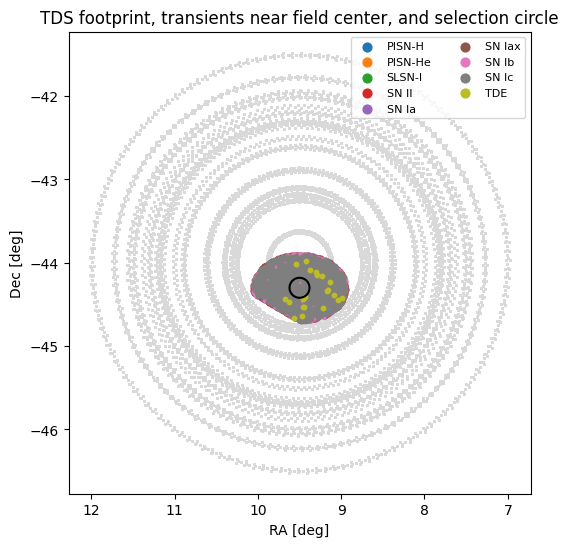

In [3]:
def load_metadata(plot=True):
    obseq = Table.read(download_file(OBSEQ_URL, CACHE_DIR / "obseq.fits")).to_pandas()
    obseq["filter"] = obseq["filter"].astype(str)
    obseq["pointing"] = obseq.index
    snana = pd.read_parquet(download_file(SNANA_PARQUET_URL, CACHE_DIR / "snana_10307.parquet"))
    snana["label"] = snana["gentype"].map(GENTYPE_LABEL)
    if plot:
        plot_field(obseq, snana)
    return obseq, snana


obseq, snana = load_metadata(plot=True)


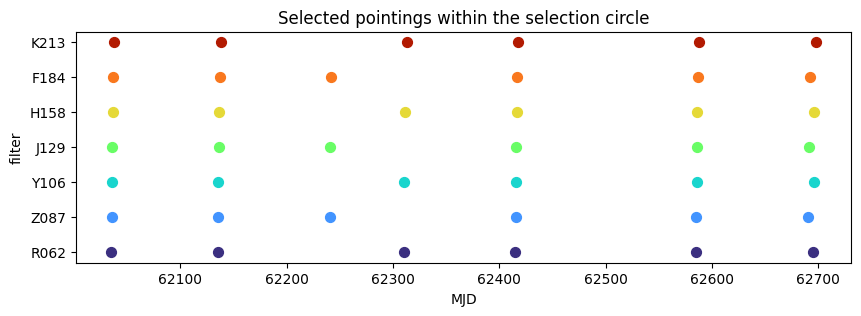

In [4]:
def select_pointings(obseq, plot=True):
    separation = angular_separation_deg(obseq["ra"], obseq["dec"],
                                        FIELD_CENTER_RA, FIELD_CENTER_DEC)
    near = obseq[separation < SELECTION_RADIUS_DEG]
    selected = []
    for band in BANDS_BY_WAVELENGTH:
        band_pointings = near[near["filter"] == band].sort_values("date")
        if len(band_pointings) == 0:
            continue
        sampling = np.linspace(0, len(band_pointings) - 1,
                               min(POINTINGS_PER_BAND, len(band_pointings))).astype(int)
        selected.append(band_pointings.iloc[sampling])
    selected = pd.concat(selected)
    if plot:
        plot_cadence(selected)
    return selected


selected_pointings = select_pointings(obseq, plot=True)


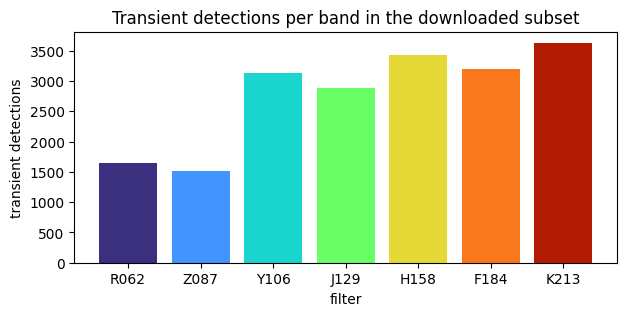

In [5]:
def download_photometry(selected_pointings, obseq, plot=True):
    tasks = [(row.filter, row.pointing, sca)
             for row in selected_pointings.itertuples()
             for sca in SCA_NUMBERS]
    with ThreadPoolExecutor(max_workers=24) as executor:
        frames = list(executor.map(lambda task: load_index_file(*task), tasks))
    photometry = pd.concat([frame for frame in frames if frame is not None and len(frame)],
                           ignore_index=True)
    photometry = photometry.merge(obseq[["pointing", "date", "exptime"]], on="pointing", how="left")
    photometry = photometry.rename(columns={"date": "mjd"})

    # Model the Roman photometric error: the source Poisson term uses the (noiseless) truth `flux`,
    # the background uses the per-band noise floor. The observed flux per epoch is the simulation's
    # own noisy measurement `realized_flux`, so SNR = realized_flux / sigma_flux.
    noise_floor = photometry["band"].map(NOISE_FLOOR_VARIANCE)
    flux_error = np.sqrt(photometry["flux"].clip(lower=0) + noise_floor)
    flux_observed = photometry["realized_flux"]
    photometry["flux_error"] = flux_error
    photometry["flux_observed"] = flux_observed
    photometry["snr"] = flux_observed / flux_error
    photometry["detected"] = photometry["snr"] >= SNR_DETECTION

    zeropoint = photometry["band"].map(ROMAN_ZEROPOINT)
    observed_rate = flux_observed / photometry["exptime"] / COLLECTING_AREA_CM2
    true_rate = photometry["flux"] / photometry["exptime"] / COLLECTING_AREA_CM2
    with np.errstate(invalid="ignore", divide="ignore"):
        photometry["mag_ab"] = np.where(flux_observed > 0, zeropoint - 2.5 * np.log10(observed_rate), np.nan)
        photometry["mag_err"] = np.where(flux_observed > 0, 1.0857 * flux_error / flux_observed, np.nan)
        photometry["mag_ab_true"] = zeropoint - 2.5 * np.log10(true_rate.clip(lower=1e-30))
    if plot:
        plot_detection_counts(photometry)
    return photometry


photometry = download_photometry(selected_pointings, obseq, plot=True)


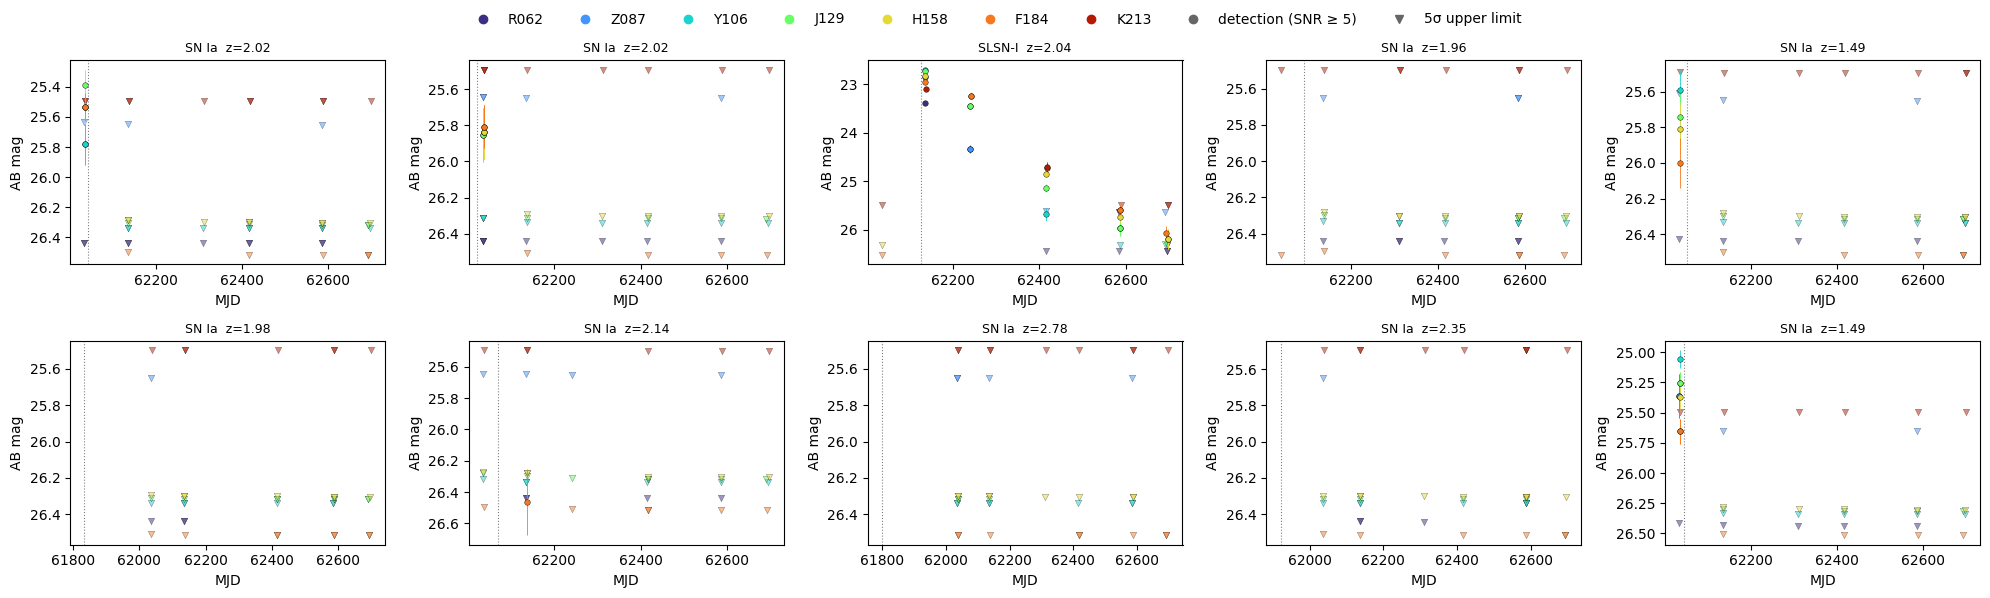

,object_id,label,z_CMB,n_epochs,n_bands
410,20214435,SN Ia,2.0151,54,7
105,20055631,SN Ia,2.0179,47,7
1929,70000029,SLSN-I,2.0404,44,7
396,20210144,SN Ia,1.9552,42,7
141,20078510,SN Ia,1.4891,40,7
258,20139438,SN Ia,1.9773,40,7
270,20144721,SN Ia,2.1360,40,7
318,20166550,SN Ia,2.7819,39,6
424,20223463,SN Ia,2.3453,39,7
86,20044909,SN Ia,1.4893,39,7


In [6]:
def build_light_curves(photometry, snana, number=NUMBER_OF_TRANSIENTS, plot=True):
    statistics = (photometry.groupby("object_id")
                  .agg(n_epochs=("mjd", "size"), n_bands=("band", "nunique"))
                  .reset_index())
    statistics = statistics.merge(snana[["id", "label", "z_CMB", "peak_mjd"]],
                                  left_on="object_id", right_on="id", how="left")
    candidates = statistics[(statistics["label"].notna())
                            & (statistics["label"] != "FIXMAG")
                            & (statistics["n_bands"] >= 3)]
    candidates = candidates.sort_values("n_epochs", ascending=False).head(number)
    light_curves = photometry[photometry["object_id"].isin(candidates["object_id"])]
    if plot:
        plot_light_curves(light_curves, candidates)
    return candidates


top_transients = build_light_curves(photometry, snana, plot=True)
top_transients[["object_id", "label", "z_CMB", "n_epochs", "n_bands"]]


## Filtro de SNR y censo de objetos — todo sin descargar imágenes

Con el SNR ya bien calibrado (sky en e⁻/pixel), aplicamos el corte de detección **per-época S/N ≥ 5**
(`photometry["detected"]`) y construimos un censo por objeto directamente desde los truth index files.
No se descarga ninguna imagen: `flux`, `realized_flux`, `mag` y la posición vienen en el index `.txt`.


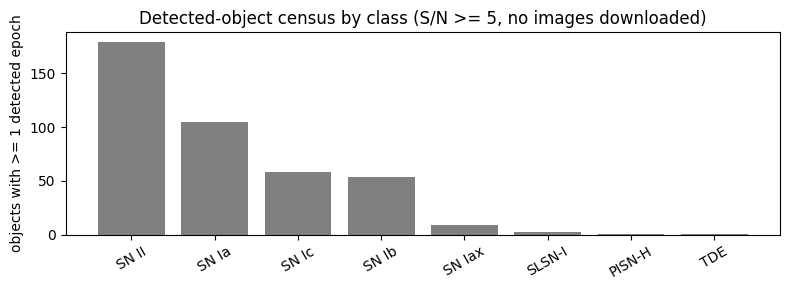

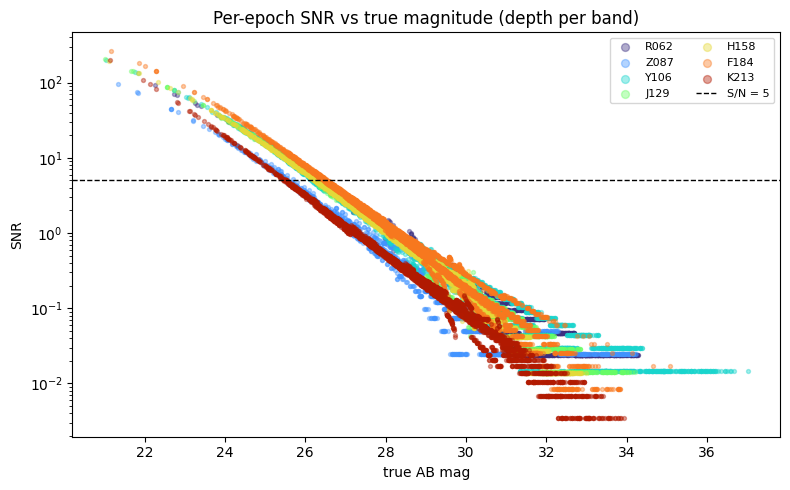

,object_id,label,z_CMB,n_epochs,n_detected,n_bands,bands_detected,max_snr,brightest_mag_true
0,50061524,SN Ic,0.5951,7,7,7,R062 Z087 Y106 J129 H158 F184 K213,265.496385,21.003614
1,80000086,PISN-H,0.4298,14,14,7,R062 Z087 Y106 J129 H158 F184 K213,180.503658,21.666488
2,30063338,SN II,0.0868,13,13,7,R062 Z087 Y106 J129 H158 F184 K213,141.355106,22.279534
3,70000029,SLSN-I,2.0404,44,26,7,R062 Z087 Y106 J129 H158 F184 K213,91.177139,22.733028
4,70000680,SLSN-I,1.5356,11,10,7,R062 Z087 Y106 J129 H158 F184 K213,84.671050,22.627375
5,30257659,SN II,0.5205,7,7,7,R062 Z087 Y106 J129 H158 F184 K213,65.330461,23.130917
6,40110663,SN Ib,0.5953,14,11,7,R062 Z087 Y106 J129 H158 F184 K213,64.344782,23.034401
7,50030941,SN Ic,0.3714,7,7,7,R062 Z087 Y106 J129 H158 F184 K213,64.285794,23.095043
8,50147657,SN Ic,0.4340,4,4,4,R062 Y106 H158 K213,62.578332,22.826009
9,30643314,SN II,0.2597,6,4,3,Z087 J129 F184,60.760859,23.540711


In [7]:
def build_object_census(photometry, snana):
    grouped = photometry.groupby("object_id")
    census = grouped.agg(
        n_epochs=("mjd", "size"),
        n_bands=("band", "nunique"),
        n_detected=("detected", "sum"),
        max_snr=("snr", "max"),
        brightest_mag_true=("mag_ab_true", "min"),
    ).reset_index()
    detected = photometry[photometry["detected"]]
    bands_detected = (detected.groupby("object_id")["band"]
                      .agg(lambda values: " ".join(sorted(set(values), key=BANDS_BY_WAVELENGTH.index))))
    census["bands_detected"] = census["object_id"].map(bands_detected).fillna("")
    census = census.merge(snana[["id", "label", "z_CMB", "peak_mjd"]],
                          left_on="object_id", right_on="id", how="left").drop(columns="id")
    return census.sort_values("max_snr", ascending=False).reset_index(drop=True)


def plot_class_census(census, plot=True):
    detected_objects = census[census["n_detected"] >= 1]
    counts = detected_objects["label"].fillna("unknown").value_counts()
    figure, axis = plt.subplots(figsize=(8, 3))
    axis.bar(counts.index, counts.values, color="0.5")
    axis.set_ylabel("objects with >= 1 detected epoch")
    axis.set_title(f"Detected-object census by class (S/N >= {SNR_DETECTION:.0f}, no images downloaded)")
    axis.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


def plot_snr_vs_mag(photometry, plot=True):
    figure, axis = plt.subplots(figsize=(8, 5))
    for band in BANDS_BY_WAVELENGTH:
        rows = photometry[photometry["band"] == band]
        axis.scatter(rows["mag_ab_true"], rows["snr"], s=8, alpha=0.4,
                     color=BAND_COLOR[band], label=band)
    axis.axhline(SNR_DETECTION, color="k", ls="--", lw=1, label=f"S/N = {SNR_DETECTION:.0f}")
    axis.set_yscale("log")
    axis.set_xlabel("true AB mag")
    axis.set_ylabel("SNR")
    axis.set_title("Per-epoch SNR vs true magnitude (depth per band)")
    axis.legend(markerscale=2, fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


object_census = build_object_census(photometry, snana)
plot_class_census(object_census, plot=True)
plot_snr_vs_mag(photometry, plot=True)
object_census[object_census["n_detected"] >= 1][
    ["object_id", "label", "z_CMB", "n_epochs", "n_detected", "n_bands",
     "bands_detected", "max_snr", "brightest_mag_true"]].head(20)


### Qué se puede hacer solo con los index files (sin descargar imágenes)

Cada `Roman_TDS_index_*.txt` (~KB, no los FITS de ~40 MB) ya trae fotometría verdadera y con ruido por
exposición. Con eso, y sin tocar una sola imagen, se puede:

- **Light curves multibanda** (`flux`, `realized_flux`, `mag`) por transiente — celda anterior.
- **SNR y flag de detección por época** con la receta de ruido de Roman (`snr`, `detected`).
- **Censo de objetos y distribución de clases** (KN vs SN vs resto) entre los detectados.
- **Cobertura de fase** respecto a `peak_mjd`: cuántas épocas con medición caen antes/después del pico.
- **Colores en épocas tempranas** (objetivo del clasificador contrastivo: 3 primeras épocas).
- **Selección de candidatos KN** para el set de entrenamiento, filtrando por clase + S/N + nº de bandas.

Las imágenes (`RomanTDS/images/...`, ~40 MB/SCA) solo hacen falta para spot-checks visuales — la celda
siguiente descarga **una sola** imagen como ejemplo.


## Ejemplo: acceder a una imagen

Las imágenes pesan ~40 MB por SCA (`RomanTDS/images/simple_model/<BAND>/<POINTING>/Roman_TDS_simple_model_<BAND>_<POINTING>_<SCA>.fits.gz`,
HDUs `SCI`/`ERR`/`DQ`, 4088x4088). Aquí se descarga **solo una**: el SCA que contiene la detección más
brillante del subconjunto, marcando la posición `(x, y)` del transiente que da el truth index.


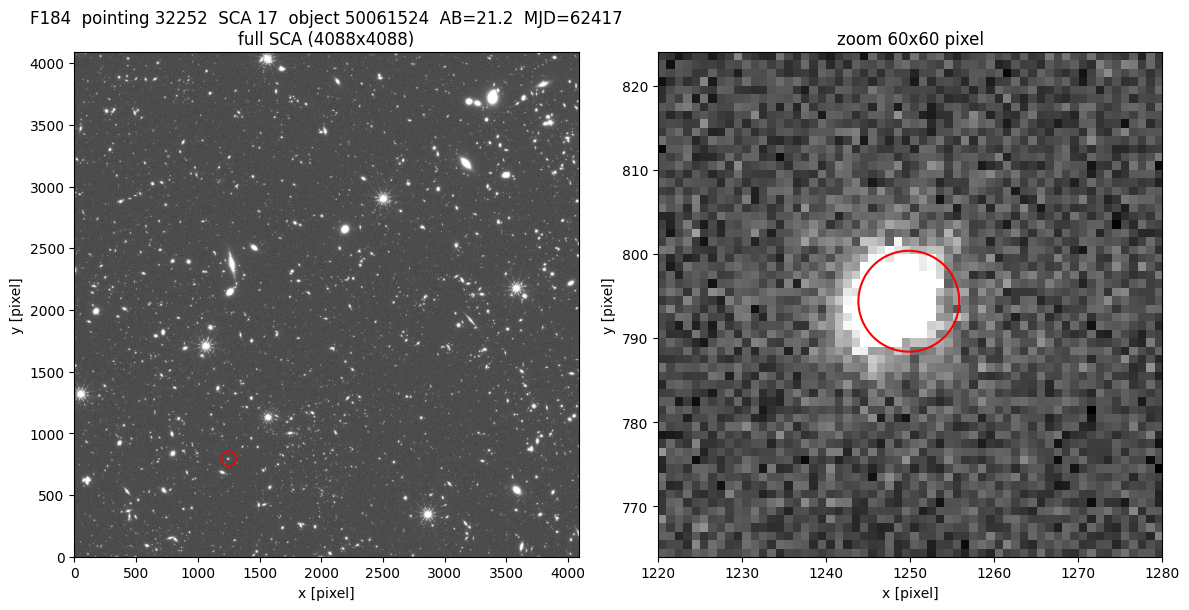

In [8]:
def show_brightest_detection_image(photometry, plot=True):
    detection = photometry.loc[photometry["realized_flux"].idxmax()]
    band, pointing, object_id = detection["band"], int(detection["pointing"]), detection["object_id"]
    science_area_arcsec = None
    found_sca, mark_xy = None, None
    for candidate_sca in SCA_NUMBERS:
        index = load_index_file(band, pointing, candidate_sca)
        if index is None:
            continue
        hit = index[index["object_id"] == object_id]
        if len(hit):
            found_sca, mark_xy = candidate_sca, (hit["x"].iloc[0], hit["y"].iloc[0])
            break
    url = f"{IMAGE_BASE}/{band}/{pointing}/Roman_TDS_simple_model_{band}_{pointing}_{found_sca}.fits.gz"
    path = download_file(url, CACHE_DIR / f"image_{band}_{pointing}_{found_sca}.fits.gz")
    science = fits.getdata(path, extname="SCI")
    title = (f"{band}  pointing {pointing}  SCA {found_sca}  "
             f"object {object_id}  AB={detection['mag_ab']:.1f}  MJD={detection['mjd']:.0f}")
    if plot:
        plot_image_with_marker(science, mark_xy, title)
    return science


science = show_brightest_detection_image(photometry, plot=True)
